In [22]:
from use_net import RelationNetPredictor

# Initialize predictor
predictor = RelationNetPredictor(
    checkpoint_path='api/best_model.pth'
)

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# For a single image
def show_prediction(image_path, predictor, support_images, support_labels):
    # Get prediction
    probability = predictor.predict_single_modified(
        query_image=image_path,
        support_images=support_images,
        support_labels=support_labels
    )
    
    # Determine prediction based on probability threshold
    prediction = 1 if probability >= 0.5 else 0
    
    # Load and display image
    img = np.array(Image.open(image_path))
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    
    # Add colored border based on prediction
    color = 'green' if prediction == 1 else 'red'
    plt.gca().spines['bottom'].set_color(color)
    plt.gca().spines['top'].set_color(color)
    plt.gca().spines['left'].set_color(color)
    plt.gca().spines['right'].set_color(color)
    plt.gca().spines['bottom'].set_linewidth(5)
    plt.gca().spines['top'].set_linewidth(5)
    plt.gca().spines['left'].set_linewidth(5)
    plt.gca().spines['right'].set_linewidth(5)
    
    # Add prediction text
    prediction_text = 'Valid' if prediction == 1 else 'Invalid'
    plt.title(f'Prediction: {prediction_text}\nConfidence: {probability:.2%}', pad=20)
    plt.axis('off')
    plt.show()

# For multiple images
def show_predictions(image_paths, predictor, support_images, support_labels, cols=3):
    # Get predictions
    probabilities = predictor.predict_batch(
        query_images=image_paths,
        support_images=support_images,
        support_labels=support_labels
    )
    
    # Create subplot grid
    rows = len(image_paths) // cols + (1 if len(image_paths) % cols != 0 else 0)
    plt.figure(figsize=(5*cols, 5*rows))
    
    for idx, (img_path, probability) in enumerate(zip(image_paths, probabilities)):
        # Determine prediction
        prediction = 1 if probability >= 0.5 else 0
        
        # Display image
        img = np.array(Image.open(img_path).convert('RGB'))
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img)
        
        # Add colored border
        color = 'green' if prediction == 1 else 'red'
        plt.gca().spines['bottom'].set_color(color)
        plt.gca().spines['top'].set_color(color)
        plt.gca().spines['left'].set_color(color)
        plt.gca().spines['right'].set_color(color)
        plt.gca().spines['bottom'].set_linewidth(5)
        plt.gca().spines['top'].set_linewidth(5)
        plt.gca().spines['left'].set_linewidth(5)
        plt.gca().spines['right'].set_linewidth(5)
        
        # Add prediction text
        prediction_text = 'Valid' if prediction == 1 else 'Invalid'
        plt.title(f'Prediction: {prediction_text}\nConfidence: {probability:.2%}', pad=20)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [24]:
from pathlib import Path

# Define support set paths
valid_dir = Path('api/support_images/valid')
invalid_dir = Path('api/support_images/invalid')

# Get all images from both directories
valid_images = list(valid_dir.glob('*.[jJ][pP][gG]'))  
invalid_images = list(invalid_dir.glob('*.[jJ][pP][gG]'))

# Convert to strings and combine
support_images = [str(path) for path in valid_images] + [str(path) for path in invalid_images]

# Create corresponding labels
support_labels = [1] * len(valid_images) + [0] * len(invalid_images)

# Print summary
print(f"Loaded {len(valid_images)} valid images and {len(invalid_images)} invalid images")
print(f"Total support images: {len(support_images)}")

Loaded 6 valid images and 8 invalid images
Total support images: 14


In [25]:
# Predict single image
result = predictor.predict_single_modified(
    query_image='query_images_invalid/eb568738-d20b-42c5-8575-ad29e2e73942.jpg',
    support_images=support_images,
    support_labels=support_labels
)

print(f"Probability: {result:.3f}")
print(f"Prediction: {'Valid' if result > 0.6 else 'Invalid'}")

Probability: 0.000
Prediction: Invalid


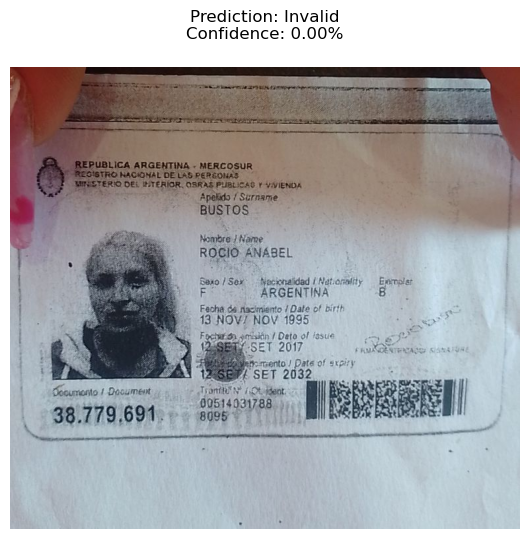

In [26]:
show_prediction('query_images_invalid/eb568738-d20b-42c5-8575-ad29e2e73942.jpg', predictor, support_images, support_labels)

In [27]:
from pathlib import Path

# Get all images from directory
query_dir = Path('query_images_valid')
query_images = list(query_dir.glob('*.jpg')) 

# Make predictions
results = predictor.predict_batch_modified(
    query_images=query_images,  
    support_images=support_images,
    support_labels=support_labels
)

# Calculate accuracy
correct = sum(1 for result in results if result > 0.5)

# Print individual results and final accuracy
for img, result in zip(query_images, results):
    print(f"{img.name}: {result}")

print(f"\nAccuracy: {correct / len(results):.2%}")

20117d34-8c44-49f3-8bfa-a4d3c109a1d2.jpg: 0.9957290291786194
test5.jpg: 0.9961208701133728
test9.jpg: 0.9960237741470337
test3.jpg: 0.9963304400444031
test4.jpg: 0.9965164661407471
e01d0842-462c-424e-8371-169dfdf7ab42.jpg: 0.9962131977081299
d406f8c3-64c2-4794-999c-d4f8b7d58128.jpg: 0.996157705783844
test6.jpg: 0.9963178634643555
test2.jpg: 0.9963982105255127
test11.jpg: 0.9955198764801025
test10.jpg: 0.9962785840034485
test1.jpg: 0.9966228008270264
05859a6c-0579-4ebb-bc96-00d90a2f8a1b.jpg: 0.9958997368812561
test8.jpg: 0.9959627985954285

Accuracy: 100.00%


In [28]:
from pathlib import Path

# Get all images from directory
query_dir = Path('query_images_invalid')
query_images = list(query_dir.glob('*.jpg')) 

# Make predictions
results = predictor.predict_batch_modified(
    query_images=query_images,
    support_images=support_images,
    support_labels=support_labels
)

# Calculate accuracy
correct = sum(1 for result in results if result < 0.5)

# Print individual results and final accuracy
for img, result in zip(query_images, results):
    print(f"{img.name}: {result}")

print(f"\nAccuracy: {correct / len(results):.2%}")

test5.jpg: 0.003909009974449873
test3.jpg: 0.0
test4.jpg: 0.0
eb568738-d20b-42c5-8575-ad29e2e73942.jpg: 0.0
test2.jpg: 0.002843653317540884
test1.jpg: 0.003396870568394661

Accuracy: 100.00%
